**Programmer:** python_scripts (Abhijith Warrier)

**PYTHON SCRIPT TO *COMPARE MULTIPLE CLASSIFICATION MODELS USING ROC CURVES AND AUC SCORES*. 🧠📈🤖**

This script demonstrates how to evaluate and compare multiple classification models using **ROC Curves** and **AUC (Area Under the Curve)**. Comparative ROC plots help identify which model separates classes more effectively across different decision thresholds.

---

## **📦 Import Required Libraries**

We’ll use scikit-learn models, evaluation metrics, and matplotlib for visualisation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score

---

## **🧩 Load the Dataset**

We’ll use a binary classification dataset suitable for ROC analysis.

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

---

## **✂️ Split Data into Train and Test Sets**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

---

## **🤖 Train Multiple Classification Models**

We train several models so their ROC curves can be compared.

In [4]:
lr = LogisticRegression(max_iter=5000)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=200, random_state=42)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


---

## **📊 Compute ROC Curves and AUC Scores**

We use predicted probabilities for the positive class.

In [5]:
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

roc_data = {}

for name, model in models.items():
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)

    roc_data[name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc_score
    }

---

## **📈 Plot Comparative ROC Curves**

Each model gets its own ROC curve on the same chart.

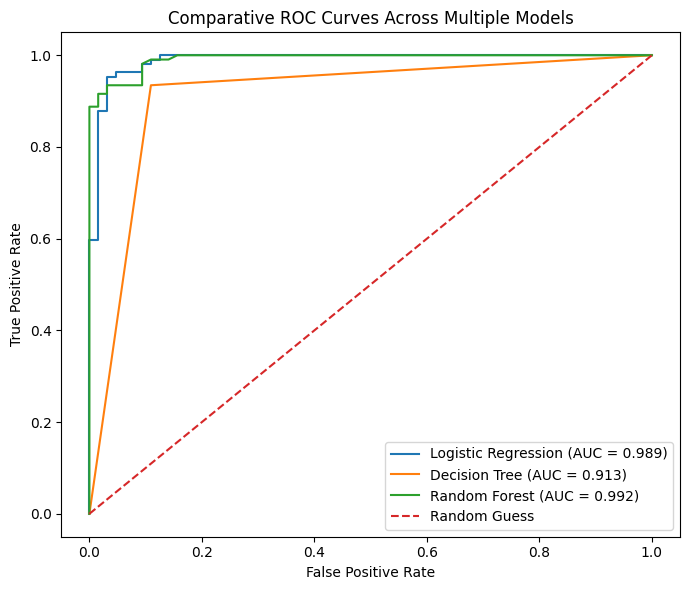

In [7]:
plt.figure(figsize=(7, 6))

for name, values in roc_data.items():
    plt.plot(
        values["fpr"],
        values["tpr"],
        label=f"{name} (AUC = {values['auc']:.3f})"
    )

# Reference line for random guessing
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparative ROC Curves Across Multiple Models")
plt.legend()
plt.tight_layout()
plt.savefig("/Users/abhijith/Downloads/roc_curves_multiple_models.png", dpi=300, bbox_inches='tight', pad_inches=0.15)
plt.show()

---

## **🔍 Why Comparative ROC Curves Are Useful**

- Compare models across **all thresholds**
- Visualise trade-off between sensitivity and false alarms
- Evaluate probability-based classifiers fairly
- Identify stronger models beyond simple accuracy

Comparative ROC curves answer:

*Which model separates positive and negative classes most effectively?*

---

## **🧠 Key Takeaways**

1. ROC curves compare classifier performance across thresholds.
2. AUC summarises overall separation ability.
3. Comparative ROC plots help rank multiple models visually.
4. Better models stay closer to the top-left corner.
5. A strong interpretability tool for binary classification evaluation.

---

## **Conclusion**

Comparative ROC curves provide a powerful way to evaluate multiple classification models on the same problem. By comparing threshold behavior and AUC scores together, we gain a more complete understanding of model quality than accuracy alone can provide.

This strengthens the **Advanced Visualisation & Interpretability** toolkit within the **AI with Python** series.

---